# Maps

The purpose of this assignment is to get practice with interactivity using the ipywidgets interface with mappable data.

**Please see Homework Prompt in PrairieLearn interface for more details on the requirements for this assignment.**

A rough outline of elements of code and write-up is shown below:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas 
import numpy as np
import bqplot
import contextily as ctx
import ipywidgets

In [2]:
# pip install ipywidgets

### Datasets Used:

#### California HQ Transit Areas: https://sandbox.data.ca.gov/dataset/ca-hq-transit-areas
- Estimated High Quality Transit Areas in the state such as major bus or rail stops 

#### Low-income or Disadvantaged Communities Designated by California: https://sandbox.data.ca.gov/dataset/low-income-or-disadvantaged-communities-designated-by-california
- US Census tracts such as those with median household incomes at or below 80 percent of the statewide median income or with median household incomes at or below the threshold designated as low income by the Department of Housing and Community Development
- The term **LIC** stands for **Low-Income Community** and the term **DAC** stands for **Disadvantaged Community**

In [3]:
gdf_transit = geopandas.read_file('CA_HQ_Transit_Areas.geojson')
gdf_lic = geopandas.read_file('Low-income_or_Disadvantaged_Communities_Designated_by_California.geojson')

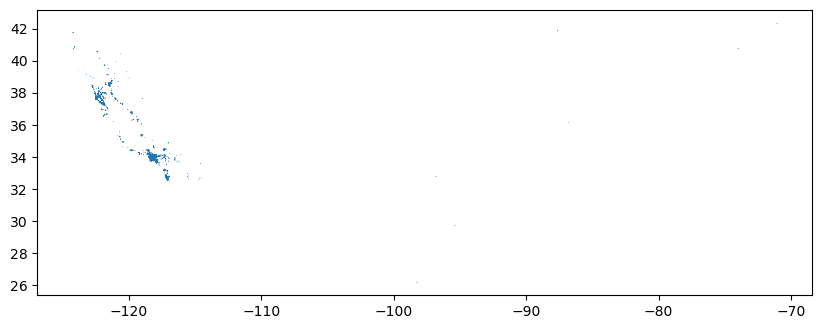

In [4]:
fig, ax = plt.subplots(figsize=(10,10))
gdf_transit.plot(ax=ax)
plt.show()

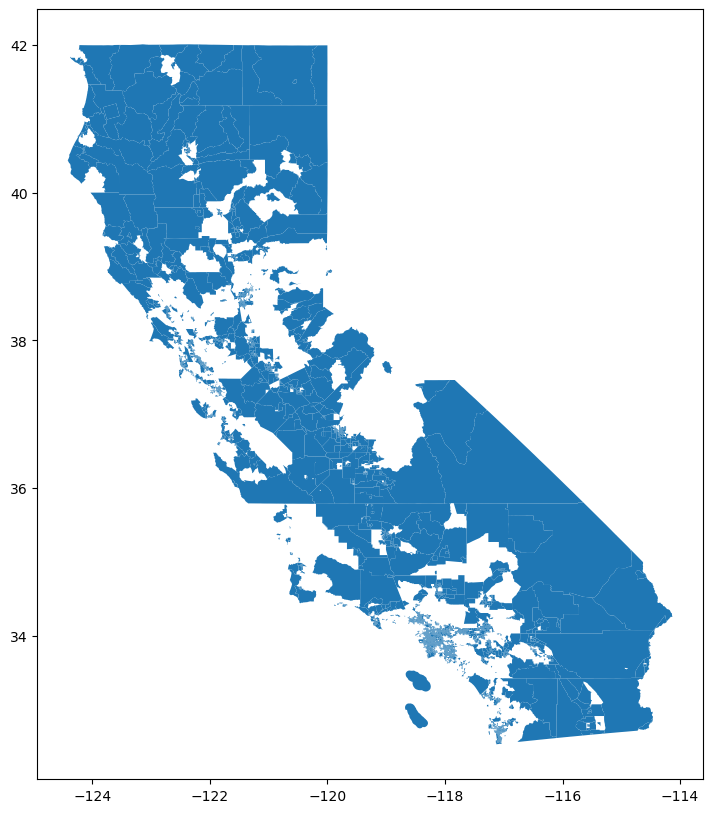

In [5]:
fig, ax = plt.subplots(figsize=(10,10))
gdf_lic.plot(ax=ax)
plt.show()

### Data Preprocessing

In [6]:
gdf_bay = gdf_lic[(gdf_lic['OBJECTID'] != 3190) & ((gdf_lic['COUNTYFP'] == '075') | (gdf_lic['COUNTYFP'] == '085') | (gdf_lic['COUNTYFP'] == '081')
                 | (gdf_lic['COUNTYFP'] == '001') | (gdf_lic['COUNTYFP'] == '013') | (gdf_lic['COUNTYFP'] == '041'))]

In [7]:
gdf_transit['hqta_type'].unique()

array(['hq_corridor_bus', 'major_stop_brt', 'major_stop_bus',
       'major_stop_ferry', 'major_stop_rail'], dtype=object)

In [8]:
bay_transit = gdf_transit[(gdf_transit['hqta_type'] != 'major_stop_ferry') &
                       ((gdf_transit['agency_primary'] == 'San Francisco Bay Area Rapid Transit District')
                      | (gdf_transit['agency_primary'] == 'Santa Clara Valley Transportation Authority') 
                       | (gdf_transit['agency_primary'] == 'Alameda-Contra Costa Transit District')
                       | (gdf_transit['agency_primary'] == 'City and County of San Francisco')
                       | (gdf_transit['agency_primary'] == 'San Mateo County Transit District')
                       | (gdf_transit['agency_primary'] == 'City of South San Francisco') 
                        | (gdf_transit['agency_primary'] == 'Marin County Transit District'))]

### Maps for Modified San Francisco Bay Area Datasets

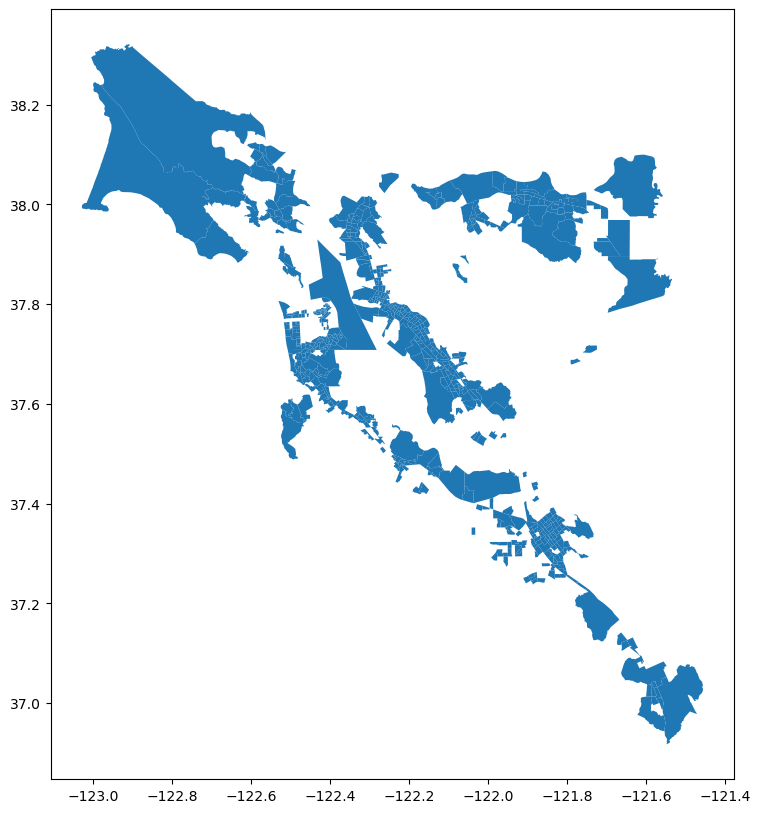

In [9]:
fig, ax = plt.subplots(figsize=(10,10))
gdf_bay.plot(ax=ax)
plt.show()

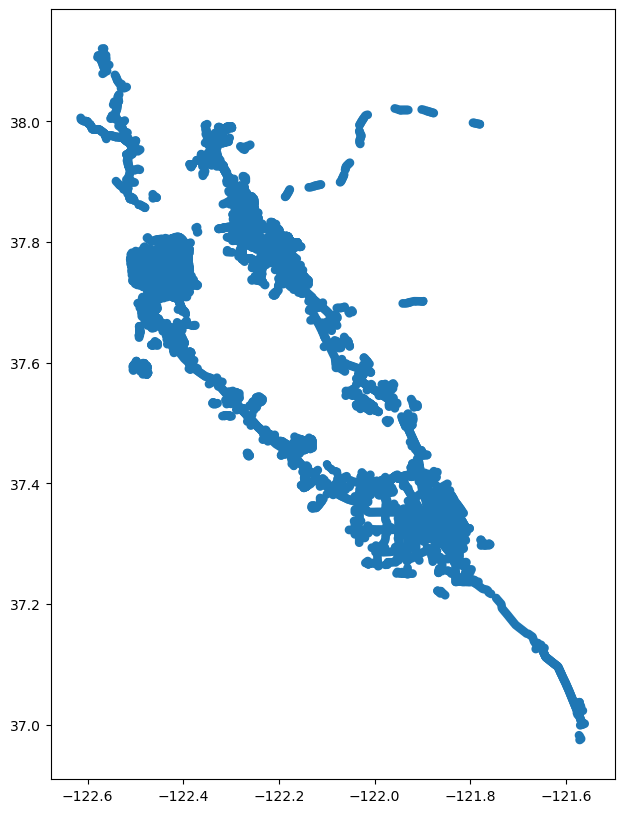

In [10]:
fig, ax = plt.subplots(figsize=(10,10))
bay_transit.plot(ax=ax)
plt.show()

In [11]:
bounds2 = bay_transit.bounds
print("X lim: (", bounds2['minx'].min(), ",", bounds2['maxx'].max(), ")")
print("Y lim: (", bounds2['miny'].min(), ",", bounds2['maxy'].max(), ")")

X lim: ( -122.62378075499998 , -121.55197873199995 )
Y lim: ( 36.96750160200003 , 38.127886197000066 )


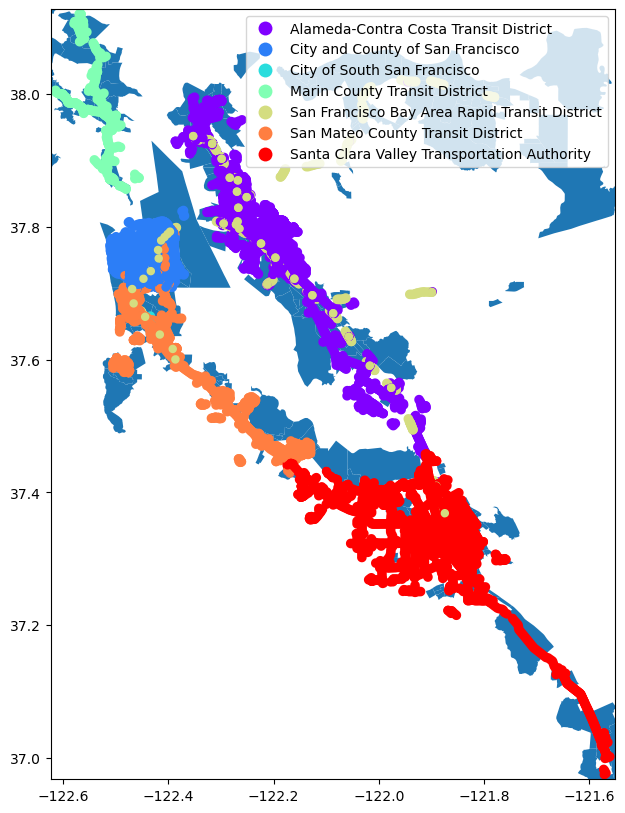

In [12]:
fig, ax = plt.subplots(figsize=(10,10))
gdf_bay.plot(ax=ax)
bay_transit.plot(column='agency_primary', cmap='rainbow', ax=ax, categorical=True, legend=True)
ax.set_xlim(-122.62378075499998 , -121.55197873199995)
ax.set_ylim(36.96750160200003 , 38.127886197000066)
plt.show()

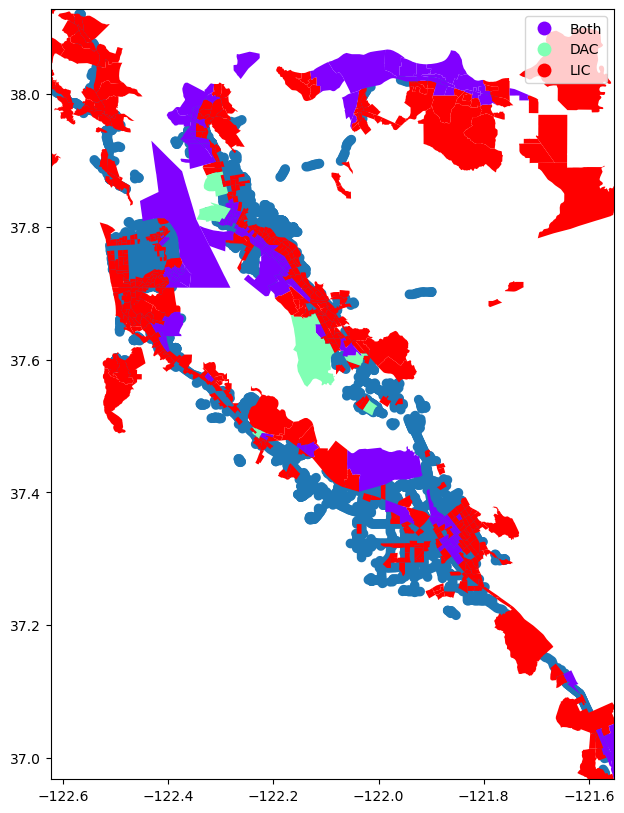

In [13]:
fig, ax = plt.subplots(figsize=(10,10))
bay_transit.plot(ax=ax)
gdf_bay.plot(column='LIC_or_DAC', cmap='rainbow', ax=ax, categorical=True, legend=True)
ax.set_xlim(-122.62378075499998 , -121.55197873199995)
ax.set_ylim(36.96750160200003 , 38.127886197000066)
plt.show()

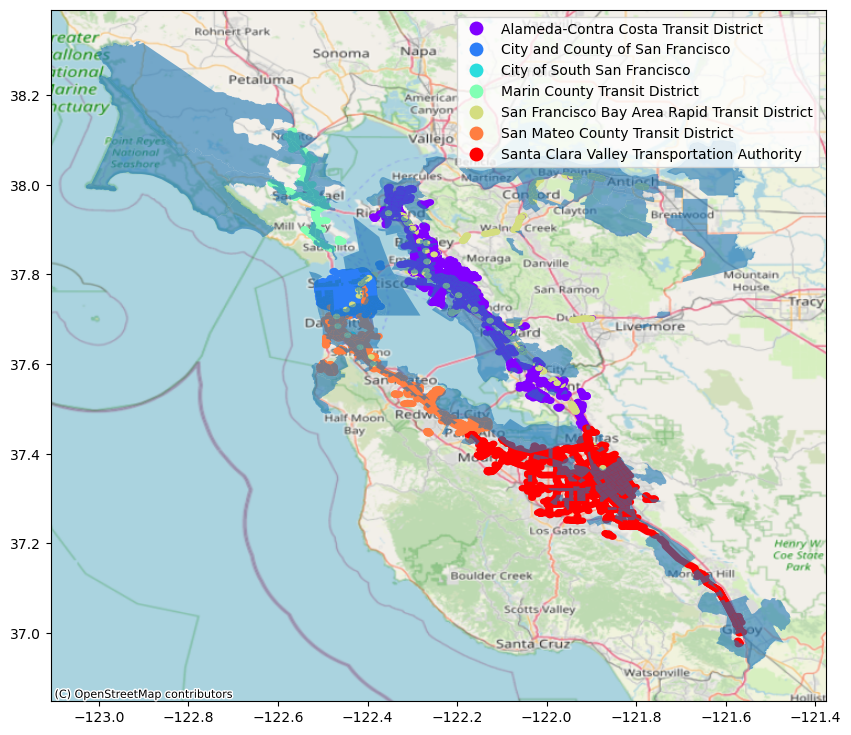

In [14]:
fig, ax = plt.subplots(figsize=(10,10))
bay_transit.plot(column='agency_primary', cmap='rainbow', ax=ax, legend=True)
gdf_bay.plot(ax=ax, alpha=0.6)
ctx.add_basemap(ax=ax, crs=bay_transit.crs, source=ctx.providers.OpenStreetMap.Mapnik)
plt.show()

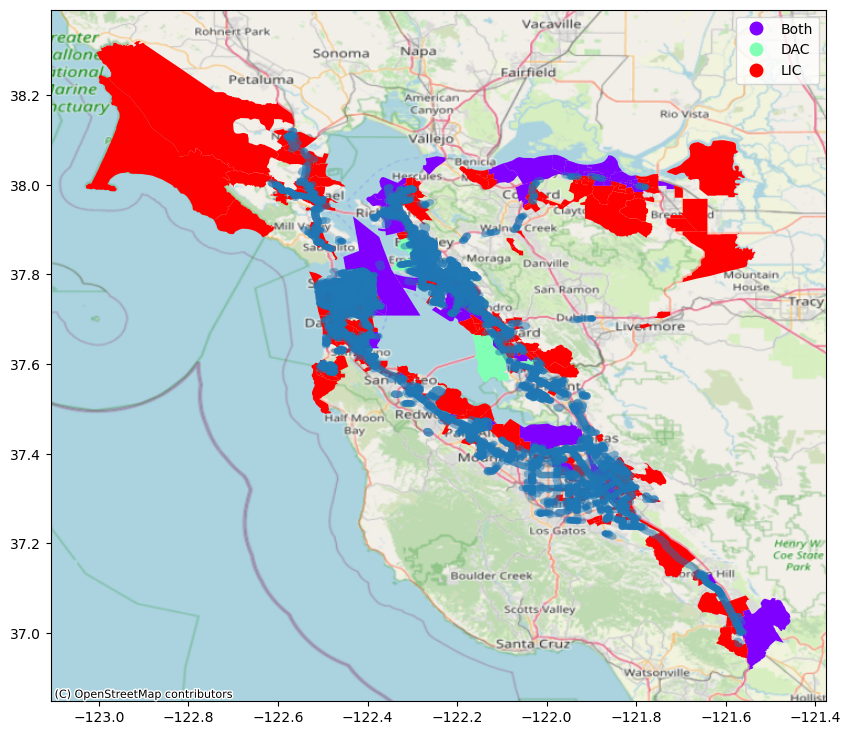

In [15]:
fig, ax = plt.subplots(figsize=(10,10))
gdf_bay.plot(column='LIC_or_DAC', cmap='rainbow', ax=ax, legend=True)
bay_transit.plot(ax=ax, alpha=0.5)
ctx.add_basemap(ax=ax, crs=bay_transit.crs, source=ctx.providers.OpenStreetMap.Mapnik)
plt.show()

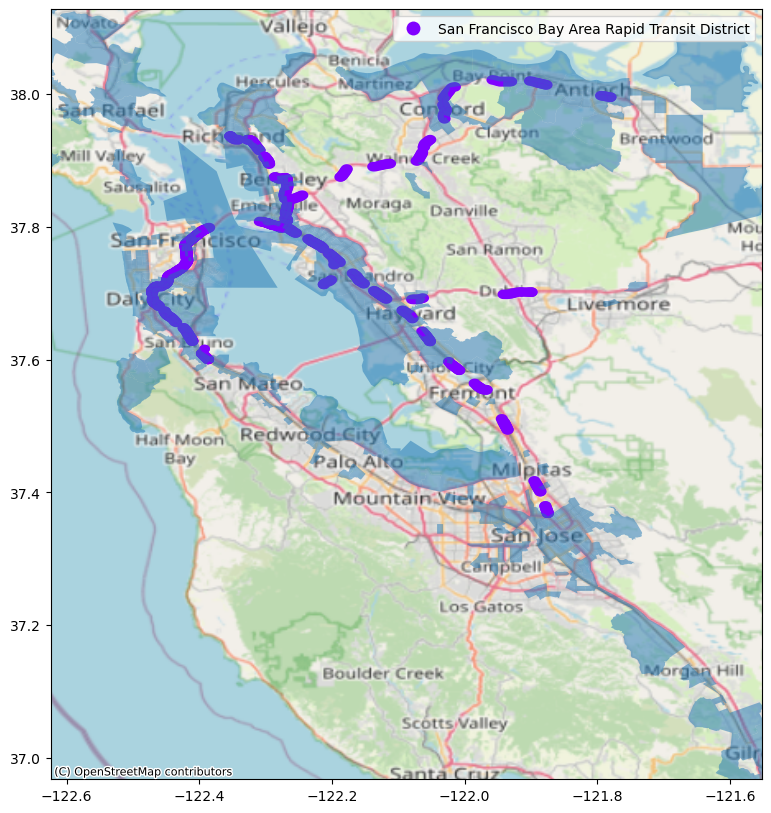

In [16]:
# Step 1: hardcode an option
transit_type = 'San Francisco Bay Area Rapid Transit District'

gdf_subset = bay_transit[bay_transit['agency_primary'] == transit_type]

fig,ax = plt.subplots(figsize=(10, 10))
gdf_subset.plot(ax=ax, column='agency_primary', cmap='rainbow', legend=True) 
gdf_bay.plot(ax=ax, alpha=0.5)
ctx.add_basemap(ax=ax, crs=bay_transit.crs, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_xlim(-122.62378075499998 , -121.55197873199995) 
ax.set_ylim(36.96750160200003 , 38.127886197000066)
plt.show()

In [17]:
def my_map_plot(transit_type):
    gdf_subset = bay_transit[bay_transit['agency_primary'] == transit_type]

    fig,ax = plt.subplots(figsize=(10, 10))
    gdf_subset.plot(ax=ax, column='agency_primary', cmap='rainbow', legend=True) 
    gdf_bay.plot(ax=ax, alpha=0.5)
    ctx.add_basemap(ax=ax, crs=bay_transit.crs, source=ctx.providers.OpenStreetMap.Mapnik)

    ax.set_xlim(-122.62378075499998 , -121.55197873199995) 
    ax.set_ylim(36.96750160200003 , 38.127886197000066)
    plt.show()

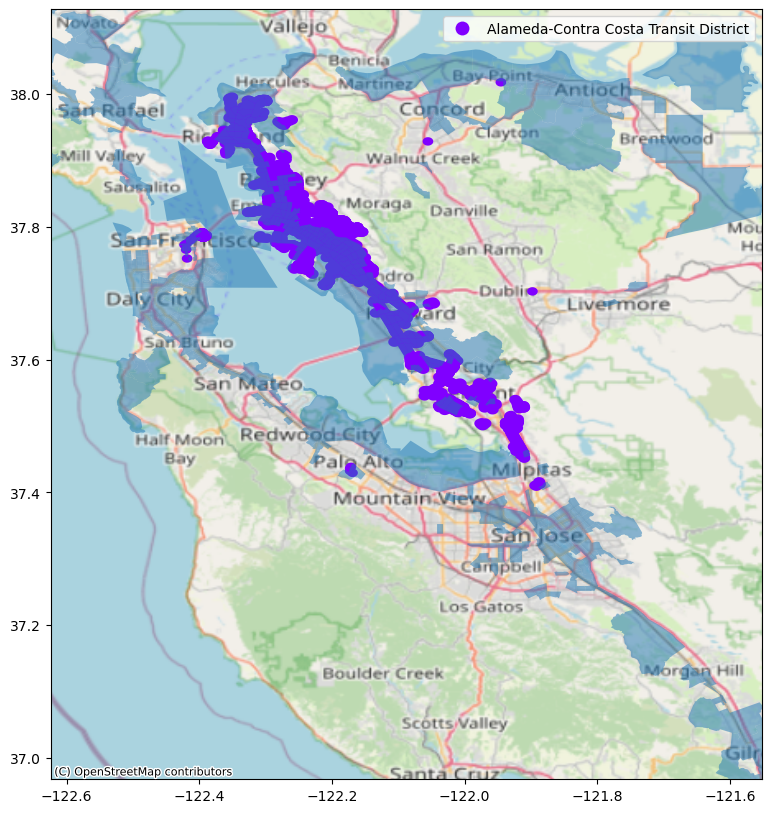

In [18]:
my_map_plot('Alameda-Contra Costa Transit District')

## Interactive Plot

In [19]:
@ ipywidgets.interact(transit_type=bay_transit['agency_primary'].unique())
def my_map_plot(transit_type):
    gdf_subset = bay_transit[bay_transit['agency_primary'] == transit_type]

    fig,ax = plt.subplots(figsize=(10, 10))
    gdf_subset.plot(ax=ax, column='agency_primary', cmap='rainbow', legend=True) 
    gdf_bay.plot(ax=ax, alpha=0.5)
    ctx.add_basemap(ax=ax, crs=bay_transit.crs, source=ctx.providers.OpenStreetMap.Mapnik)

    ax.set_xlim(-122.62378075499998 , -121.55197873199995) 
    ax.set_ylim(36.96750160200003 , 38.127886197000066)
    plt.show()

interactive(children=(Dropdown(description='transit_type', options=('Alameda-Contra Costa Transit District', '…

In [20]:
@ ipywidgets.interact(community=gdf_bay['LIC_or_DAC'].unique())
def my_map_plot(community):
    gdf_subset = gdf_bay[gdf_bay['LIC_or_DAC'] == community]

    fig,ax = plt.subplots(figsize=(10, 10))
    gdf_subset.plot(ax=ax, column='LIC_or_DAC', cmap='rainbow', legend=True) 
    bay_transit.plot(ax=ax, alpha=0.5)
    ctx.add_basemap(ax=ax, crs=bay_transit.crs, source=ctx.providers.OpenStreetMap.Mapnik)

    ax.set_xlim(-122.52021129299999, -121.55197873199995) 
    ax.set_ylim(36.96750160200003 , 38.127886197000066)
    plt.show()

interactive(children=(Dropdown(description='community', options=('Both', 'LIC', 'DAC'), value='Both'), Output(…

## Write Up

Please include 1-2 paragraphs explaining your visualization and the user interaction that you are implementing:

 * What are you trying to show? 
 * What projection are you using and why?
 * What did you find interesting? 
 * Who do you think would be interested in using this visualization? 

For this assignment I decided to create visualizations depicting the San Francisco Bay Area region and my hometown of San Jose, California. Knowing that public transportation infrastructure is a long-standing issue in California, I thought it would be interesting to display a map of low-income and disadvantaged communities from the census in relation to state-designated *high quality* transportation routes within 6 major Bay Area counties (Santa Clara, San Francisco, Alameda, Contra-Costa, San Mateo, Marin). The datasets I found consisted of data for the entire state so I had to create subsets to only include the region I was focusing on and exclude transportation methods such as ferries. After layering the maps, I found it interesting yet not surprising how some parts of the low-income communities did not have high-quality public transit routes running through them or how wealthier cities such as Palo Alto, Mountain View, or San Ramon did not have very many LIC or DAC areas.

I think visualizations and projections such as these are important to highlighting disparities in access to transportation and recognizing inefficient public transportation routes. Transportation agencies, policymakers, various city officials, or the general public would probably be interested in using a visualization like this.